<h1><center>Modélisation de l’extension des cours d’eau et de leur hydrologie </center></h1>

**Objectif : Vous allez générer un bassin versant, récupérer les données existantes sur ce bassin versant et modéliser son fonctionnement hydrogéologique pour étudier l’extension du réseau hydrographique et le débit de la rivière.** 

Les groupes impairs travaillent sur le bassin du Canut, les groupes pairs travaillent sur le bassin versant du Nançon. Ces deux bassins sont très importants pour Eau du Bassin rennais (partenaires de votre master !). Le bassin versant du Canut alimente la retenue de la Chèze qui peut stocker 14 Mm3, c’est le plus gros barrage du département. Le bassin versant du Nançon est l’un des bassins versants qui alimentent le Couesnon et les drains de Fougères, deux sources de prélèvement en surface d’eau. 

On considèrera que l’aquifère sur ces deux bassins a une épaisseur de 30m. 

Vous devez me rendre, par groupe, votre fichier jupyter, annoté du mieux possible, et si vous le souhaitez un document word qui rassemble par exemple des cartes que vous auriez faites avec QGis. 
Il est attendu que vous obteniez : 
- **Le bassin versant que vous avez extrait automatiquement** : au minimum une carte avec le bassin versant, son hydrogéologie, les stations hydrométriques et ondes sur le bassin.

- **Les données climatiques sur le bassin versant** : au minimum donner la valeur de la recharge et du ruissellement moyen annuel sur le site et faire une figure de la variabilité interannuelle. Attention aux unités.

- **Faire tourner le modèle Modflow sur votre bassin versant pour différentes valeurs pertinentes de la perméabilité (K).** Reportez dans un graphique comment l’évolution de K affecte l’extension du réseau hydrographique sur votre bassin. Caler votre modèle, c’est-à-dire trouver la valeur de K qui permette de reproduire au mieux l’extension du réseau hydrologique.

- **Vous pouvez essayer de faire tourner votre modèle en régime transitoire, à l’échelle mensuelle sur les années 2000-2003.** Pour cela, vous devez extraire la recharge uniquement sur les années qui vous intéressent et ensuite « rééchantillonner » cette recharge avec un pas de temps mensuel. Normalement, le modèle tourne sur plusieurs « stress periods » et plusieurs « time », combien ? 

- Pour visualiser et mettre en valeur vos résultats, vous disposez des rasters créés dans votre dossier de simulation (que vous pouvez regarder sur Qgis), vous pouvez également utiliser la fonction de visualisation. 

- Enfin, vous allez obtenir des résultats de outflow_drain, qui correspondent au débit de la rivière lié aux résurgence d’eau de la nappe à chaque pas de temps. Que devez-vous ajouter pour obtenir le débit total de la rivière ? Vous pouvez ensuite comparer les débits simulés avec les débits observés. En faisant varier la porosité, comment évolue le débit de la rivière ? 

Dans la dernière demi-heure, vous allez rassembler les résultats obtenus sur chaque site et me proposer collectivement des valeurs de perméabilité et de porosité pour chaque site et enfin m’expliquer le fonctionnement hydrologique des sites et les comparer.

Vous trouverez ci-dessous des blocs de commande qui permettent de réaliser les différentes étapes demandées. A vous de réorganiser ces blocs de commande et de les modifier pour obtenir vos résultats.


### 1. Charger les librairies python

In [1]:
# Libraries installed by default
import sys
import glob
import os
import fnmatch
import random
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".* .*", category=DeprecationWarning)
# Libraries need to be installed if not
import numpy as np
import pandas as pd
import shutil
from geopy.geocoders import Nominatim
# Libraries added from 'conda install' procedure
import geopandas as gpd
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.pylab as pl
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Libraries added from 'conda forge' procedure
from osgeo import gdal, osr # or import gdal
import rasterio
# Libraries installed from the pip procedure
import deepdish as dd
import flopy
import imageio
import vedo
import hydroeval
import xarray	
import netCDF4
import matplotlib_scalebar	
import contextily
import pyproj # uninstall before install
import selenium
import shapefile # named pyshp for install
import jupyter
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

C:\Users\ronan\anaconda3\envs\hydromodpy-0.1\lib\site-packages\whitebox\whitebox_tools.py:47: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\ronan\anaconda3\envs\hydromodpy-0.1\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
C:\Users\ronan\anaconda3\envs\hydromodpy-0.1\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/lates

### 2. Renseigner les répertoires utilisés et importer les classes Hydromodpy utilisées

In [2]:
#Répertoire d'Hydromodpy
from os.path import dirname, abspath
root_dir = dirname(dirname(os.getcwd()))
sys.path.append(root_dir)
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    # print("Root path directory is: {0}".format(cwd))
sys.path.append(root_dir)
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    print("Root path directory is: {0}".format(cwd))

root_dir = 'C:/Users/ronan/Local/GITHUB/HydroModPy-0.1/'
sys.path.append(root_dir)
print(root_dir)
modflow_path = os.path.join(root_dir,'bin/')

#Importer les fichiers sources hydromodpy
import src # import the folder src from HydroModpy codes
import importlib # 
importlib.reload(src)
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

# Repertoire des données utilisées -> A compléter en fonction de ou vous avez stocké vos données 
data_path = 'C:/Users/ronan/Local/GITHUB/HydroModPy-0.1/teaching/bouchez/data/'
watershed_name = 'Canut' 
# watershed_name = 'Nancon' 

# Repertoire des résultats produits -> A compléter en fonction de ou vous voulez stocker vos résultats
out_path = 'C:/Users/ronan/Local/SIMULATIONS/TEACHING/'
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'

C:/Users/ronan/Local/GITHUB/HydroModPy-0.1/


### 3. Création du Bassin Versant

In [3]:
dem_path = data_path + 'regional dem.tif' #Modifier avec le nom du DEM
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = None # [path, buffer size]
from_xyv = [327816.965, 6777886.670, 150, 10 , 'EPSG:2154'] # A modifier avec [x, y, snap distance, buffer size, crs proj]
bottom_path = None # path
load=True
save_object=True

#%% GEOGRAPHIC
print('##### '+watershed_name.upper()+' #####')
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path 
                              save_object=save_object)

##### CANUT #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Object was loaded successfully


Extract geology from specific data
Extract hydrography from specific data
Extract hydrometry from specific data
Extract intermittency from specific data


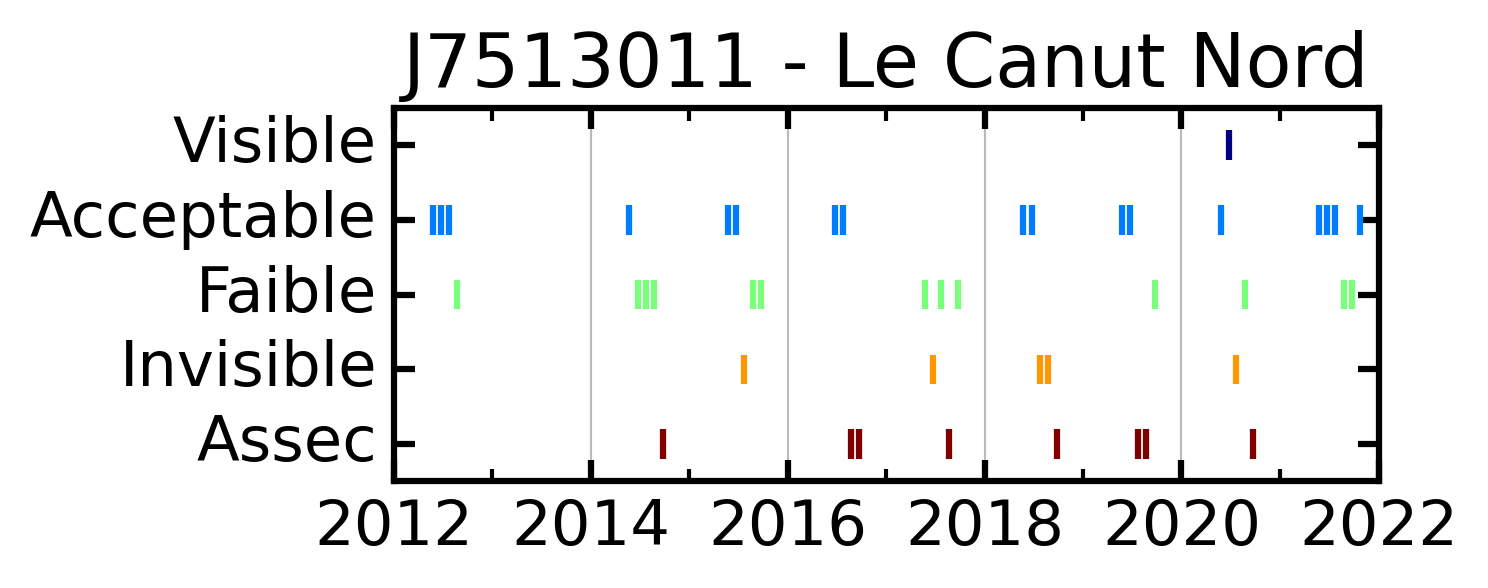

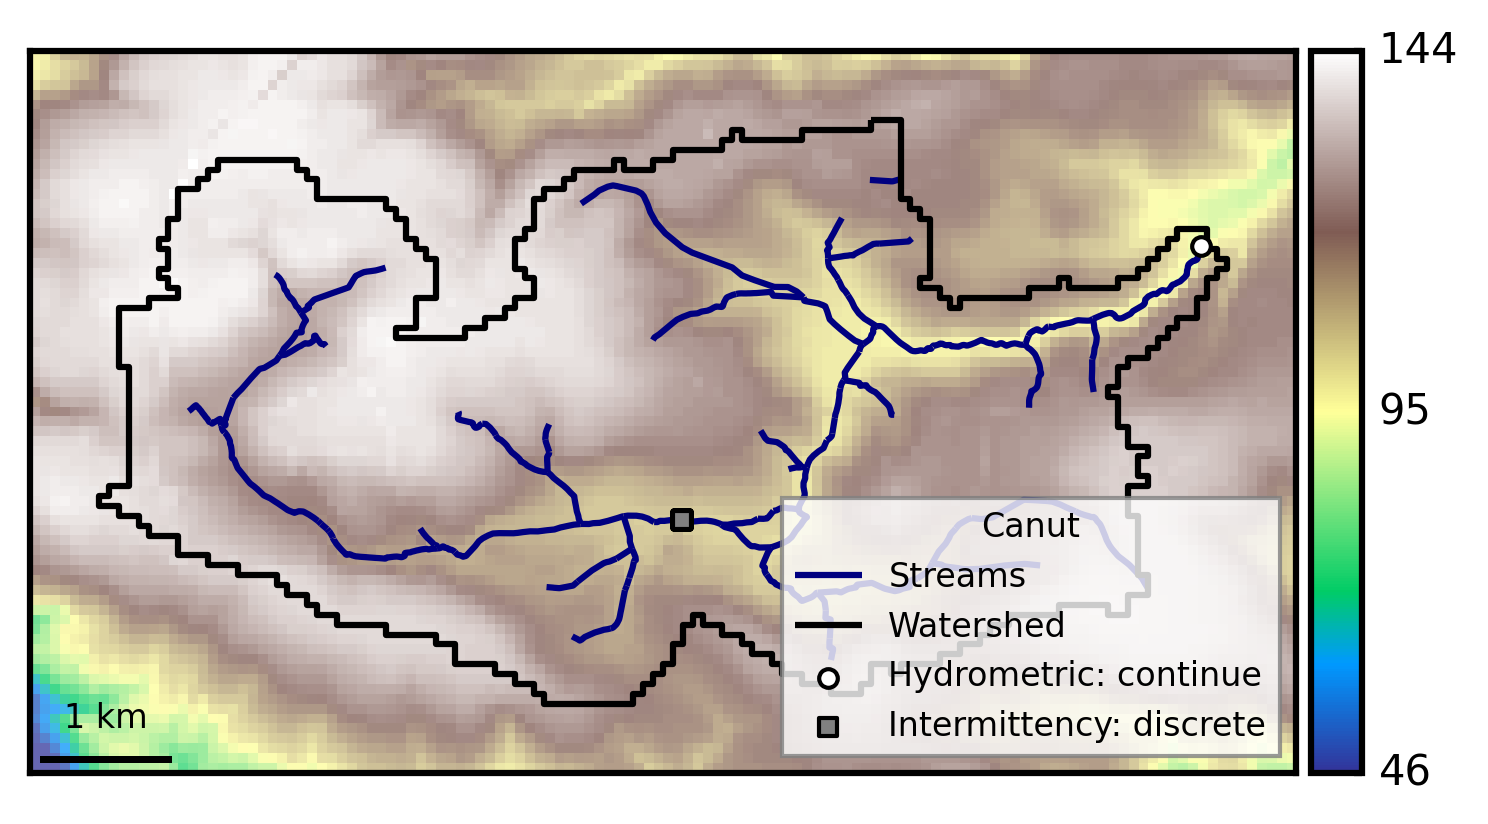

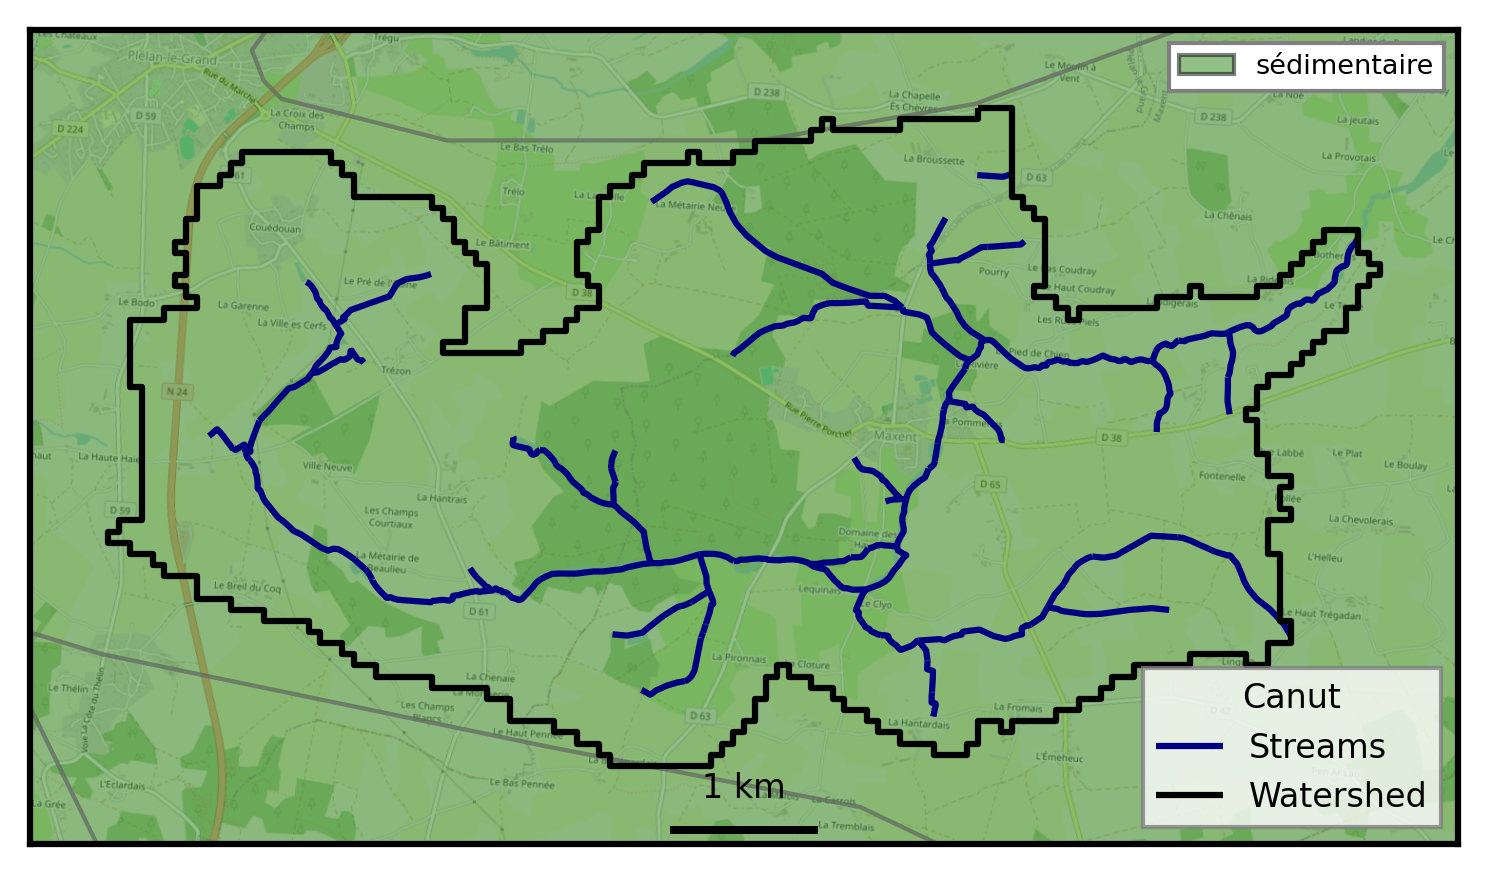

In [4]:
BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
BV.add_hydrography(data_path, types_obs=['regional stream network'])
BV.add_hydrometry(data_path, 'france hydrometric stations.shp')
BV.add_intermittency(data_path, 'regional onde stations.shp')

visualization_watershed.watershed_dem(BV)
visualization_watershed.watershed_geology(BV)

### 4. Extraction des données climatiques qui seront utilisées pour la modélisation

Init climatic module to set model parameter


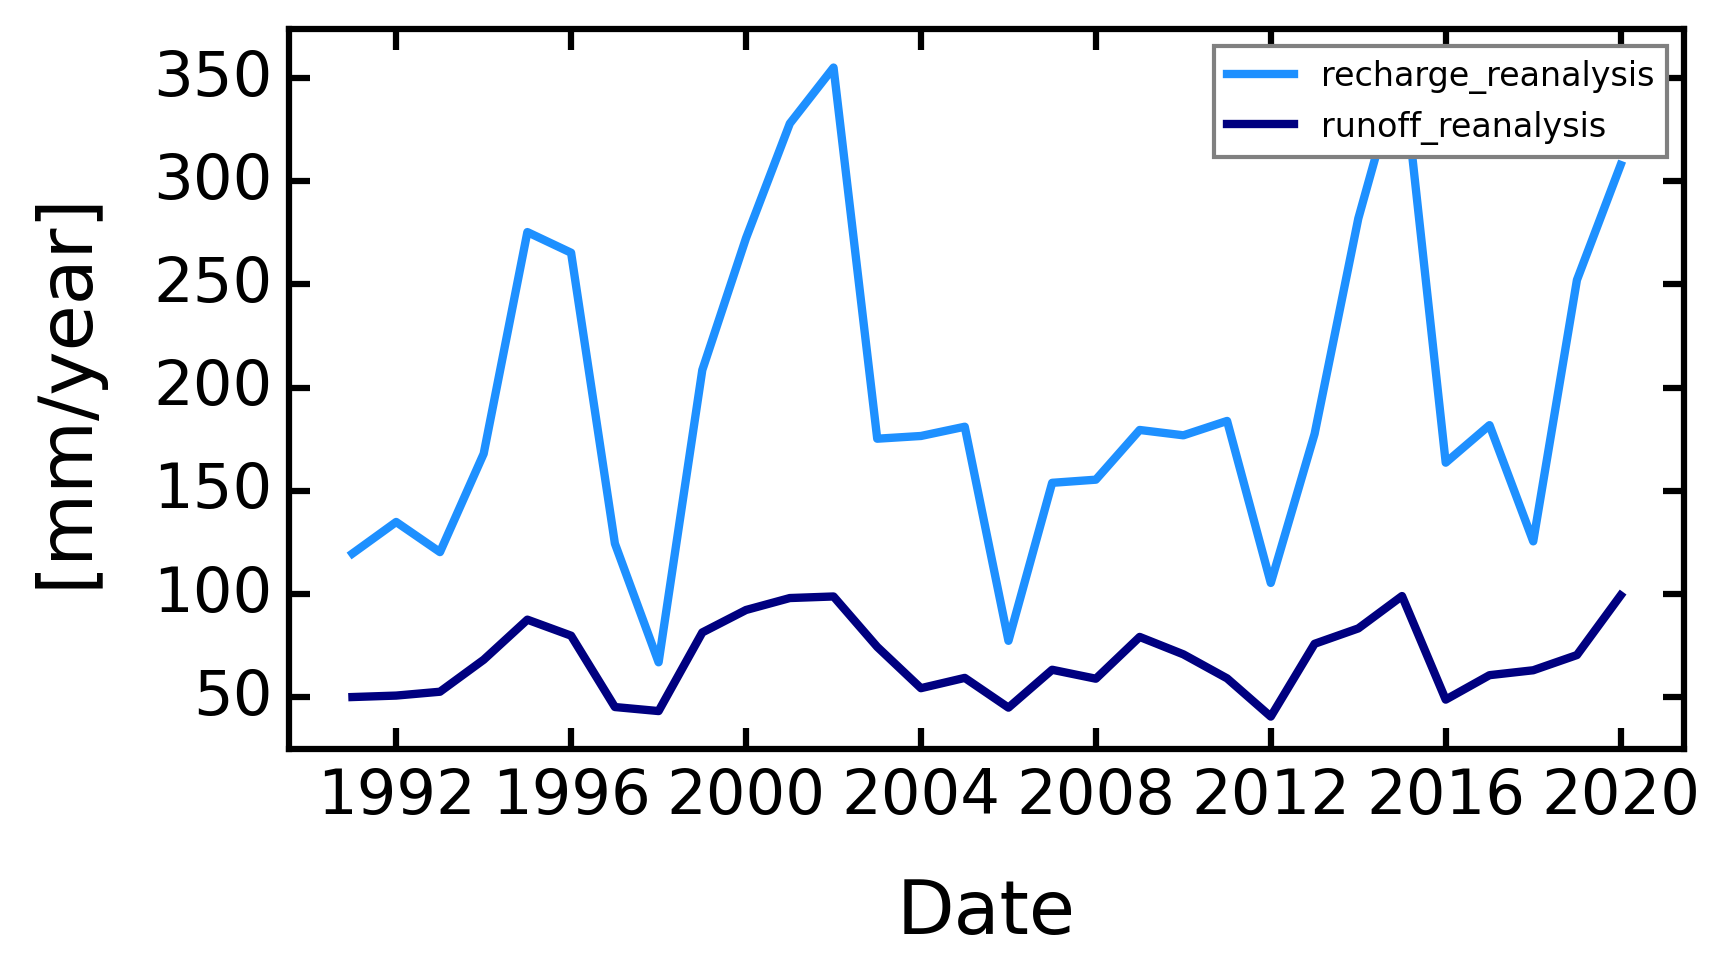

In [5]:
BV.add_climatic()
#Ici vous pouvez changer la période sur laquelle sont extraites les données climatiques, ainsi que le pas de temps

BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')
#Lignes de code permettant de rééchantillonner les données climatiques : ici pour obtenir les valeurs annuelles
Rd = BV.climatic.recharge
rd = BV.climatic.runoff
Ry = BV.climatic.recharge.resample('Y').sum()
ry = BV.climatic.runoff.resample('Y').sum()

#Représentation graphique des résultats
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(Ry, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(ry, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/year]')
ax.legend()

### 5. Caractéristiques de l'aquifère modélisé et modélisation

In [13]:
sim_state = 'steady' # transient
sim_state = 'transient' # transient

# Caractéristiques de l'aquifère - pas nécessaires de les modifier à ce stade
box = True # or False
sink_fill = False # or True
plot_cross = False
first_clim = 'mean'
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant aquifer thickness, or 2D matrix
thick = 30 # if bottom is None, aquifer thickness
cond_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
verti_cond = None
cond_drain = None
poro_decay = 0
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

# Ajout de ces caractéristiques à l'objet Bassin Versant qui va être modélisé
BV.add_settings()
BV.add_geometric()
BV.add_hydraulic()
BV.add_oceanic(sea_level)

BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_active_plot(plot_cross=plot_cross)
BV.settings.update_bc_sides(bc_left, bc_right)

BV.climatic.update_recharge(toolbox.select_period(Rd.resample('M').mean()/1000, 2000, 2005), sim_state=sim_state)
BV.climatic.update_runoff(toolbox.select_period(rd.resample('M').mean()/1000, 2000, 2005), sim_state=sim_state)
BV.climatic.update_first_clim(first_clim)

BV.hydraulic.update_nlay(nlay)
BV.hydraulic.update_lay_decay(lay_decay)
BV.hydraulic.update_bottom(bottom)
BV.hydraulic.update_thick(thick)
BV.hydraulic.update_cond_vertical(verti_cond)
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_lay_decay(poro_decay)

#Paramètres de l'aquifère -> Variables importantes à modifier pour voir l'effet sur les résultats de modélisation
porosity = 0.1 / 100 # 
hyd_cond = 1e-5 * 24 * 3600 # Attention, ici l'unité doit être similaire à la recharge !!

# Ajout de ces paramètres à l'objet Bassin Versant qui va être modélisé
BV.hydraulic.update_porosity(porosity)
BV.hydraulic.update_hyd_cond(hyd_cond)

# Choix du régime permanent ou transitoire pour faire tourner le modèle
sim_state = 'steady' # 'steady' or 'transient'

model_name = 'simulations'+'_k_'+str(round(hyd_cond,3))+'_porosity_'+str(round(porosity,3))+'_rech_'+str(Ry.mean().round(3))
BV.settings.update_model_name(model_name)
print(model_name)
print('Recharge', BV.climatic.recharge)
# print('K/R', BV.hydraulic.hyd_cond.mean() / BV.climatic.recharge)

Init settings module to set model parameter
Init hydraulic module to set model parameter
simulations_k_0.864_porosity_0.001_rech_195.041
Recharge 2000-01-31    0.002088
2000-02-29    0.000761
2000-03-31    0.000551
2000-04-30    0.000643
2000-05-31    0.000746
                ...   
2005-08-31    0.000009
2005-09-30    0.000006
2005-10-31    0.000054
2005-11-30    0.000161
2005-12-31    0.000817
Freq: M, Name: REC_REA_historic, Length: 72, dtype: float64


In [14]:
# Si on veut conserver tous les modèles réalisés, on peut les garder dans une liste
list_model_name = []
list_success_modflow = []
list_model_modflow = []

# Le modèle tourne avec les commandes suivantes : (et donc tous les attributs de BV donnés avant)
model_modflow = BV.preprocessing_modflow(for_calib=False)
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation = True,
                              watertable_depth= True, 
                              seepage_areas = True,
                              outflow_drain = True,
                              groundwater_flux = True,
                              groundwater_storage = True,
                              accumulation_flux = True,
                              export_all_tif = False)

list_model_name.append(model_name)
list_success_modflow.append(success_modflow)
list_model_modflow.append(model_modflow)

FloPy is using the following executable to run the model: C:\Users\ronan\Local\GITHUB\HydroModPy-0.1\bin/win\mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: simulations_k_0.864_porosity_0.001_rech_195.041.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2024/03/14 16:50:06

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     4    Time step:     1    Groundwater-Flow Eqn.
 Solvi

#### 6. Résultats du modèle en carte

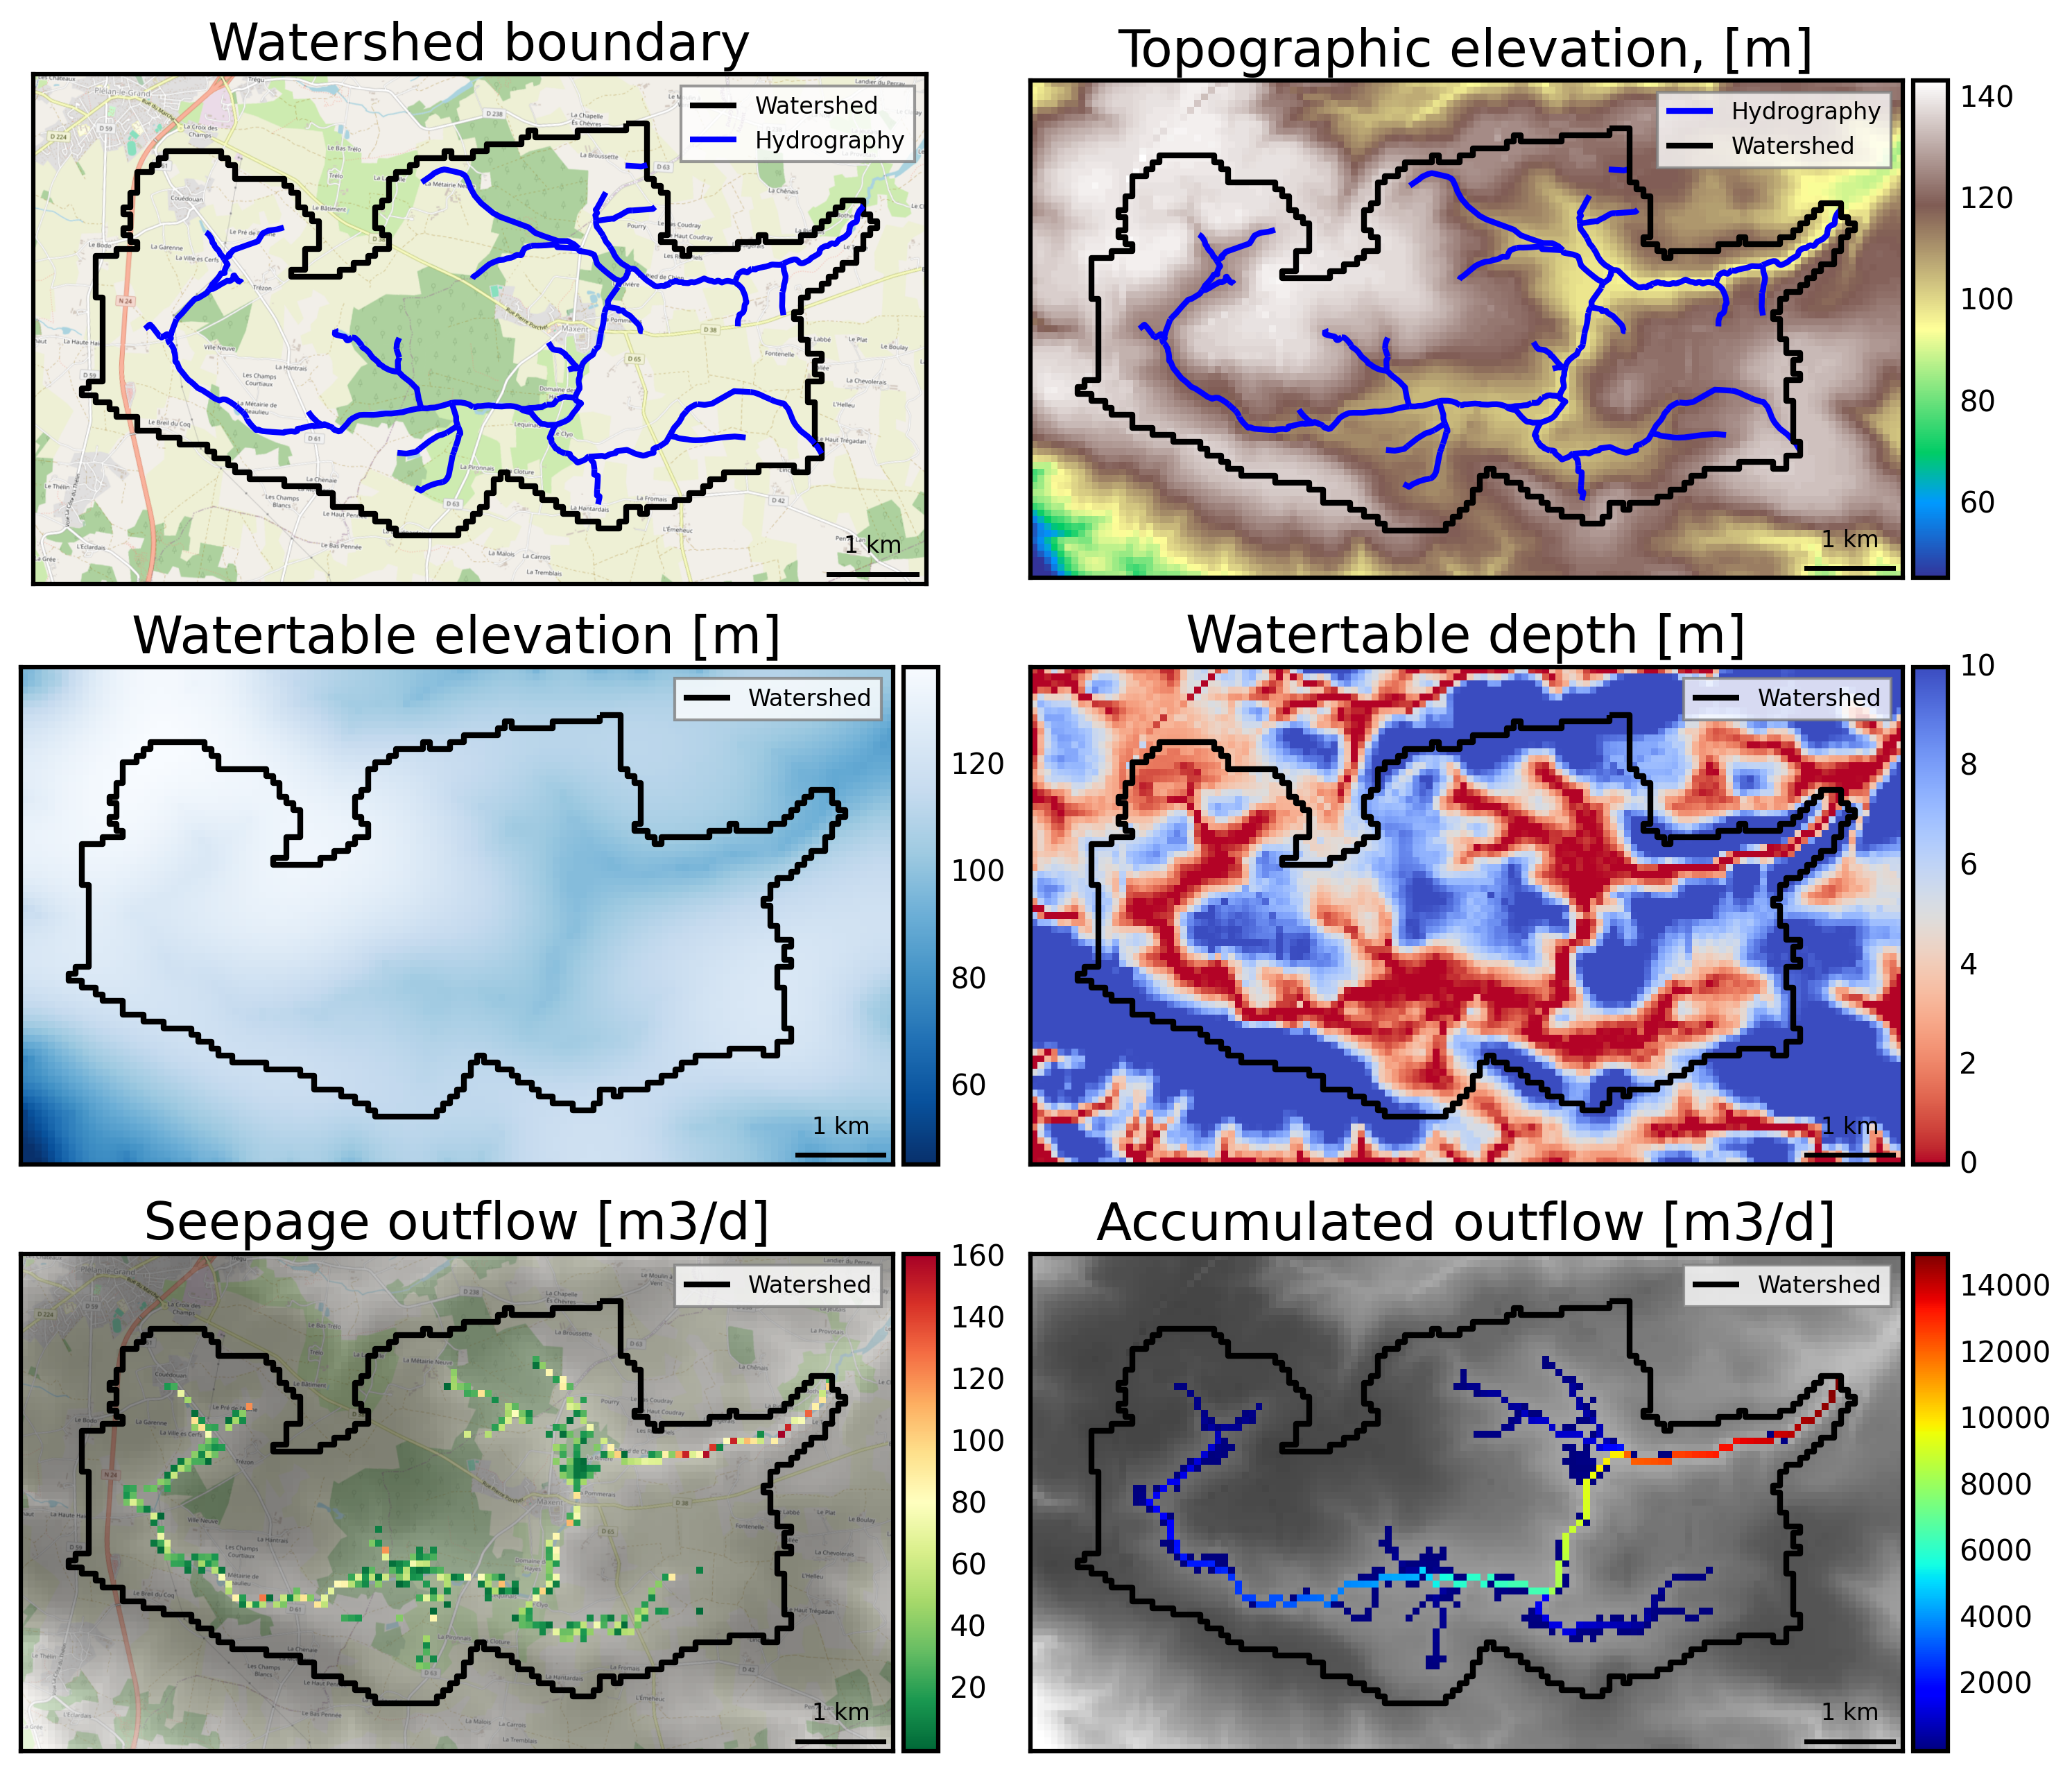

In [8]:
dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_box_buff_dem.tif') # dem data
stream_data = imageio.imread(stable_folder+'/hydrography/'+'regional stream network.tif') # river data
watertable_data = imageio.imread(simulations_folder+model_name+'/_postprocess/_rasters/'+'watertable_elevation_t(0).tif') # watertable data
visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = ['map','grid',
                             'watertable', 'watertable_depth',
                             'drain_flow','surface_flow',
                             #'pathlines', 'residence_times'
                             ],
              color_scale = [(None,None),(None,None),
                             (None,None),(0,10),
                             (None,None),(None,None),
                             #(None,None),(None,None),
                             ], 
              lines=100)

In [9]:
# visu.interactive_cross_section(dem_data, watertable_data, stream_data, interactive=True)

#### 7. Résultats quantitatifs

In [15]:
timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=None,
                                                  actual_date=True, 
                                                  subbasin_results=False)
timeseries = pd.read_csv(simulations_folder+model_name+'/_postprocess/'+'_timeseries/'+'_simulated_timeseries.csv',
                         sep=';', index_col=0, parse_dates=True)
# print(timeseries)

Extract modflow and modpath results in timeseries


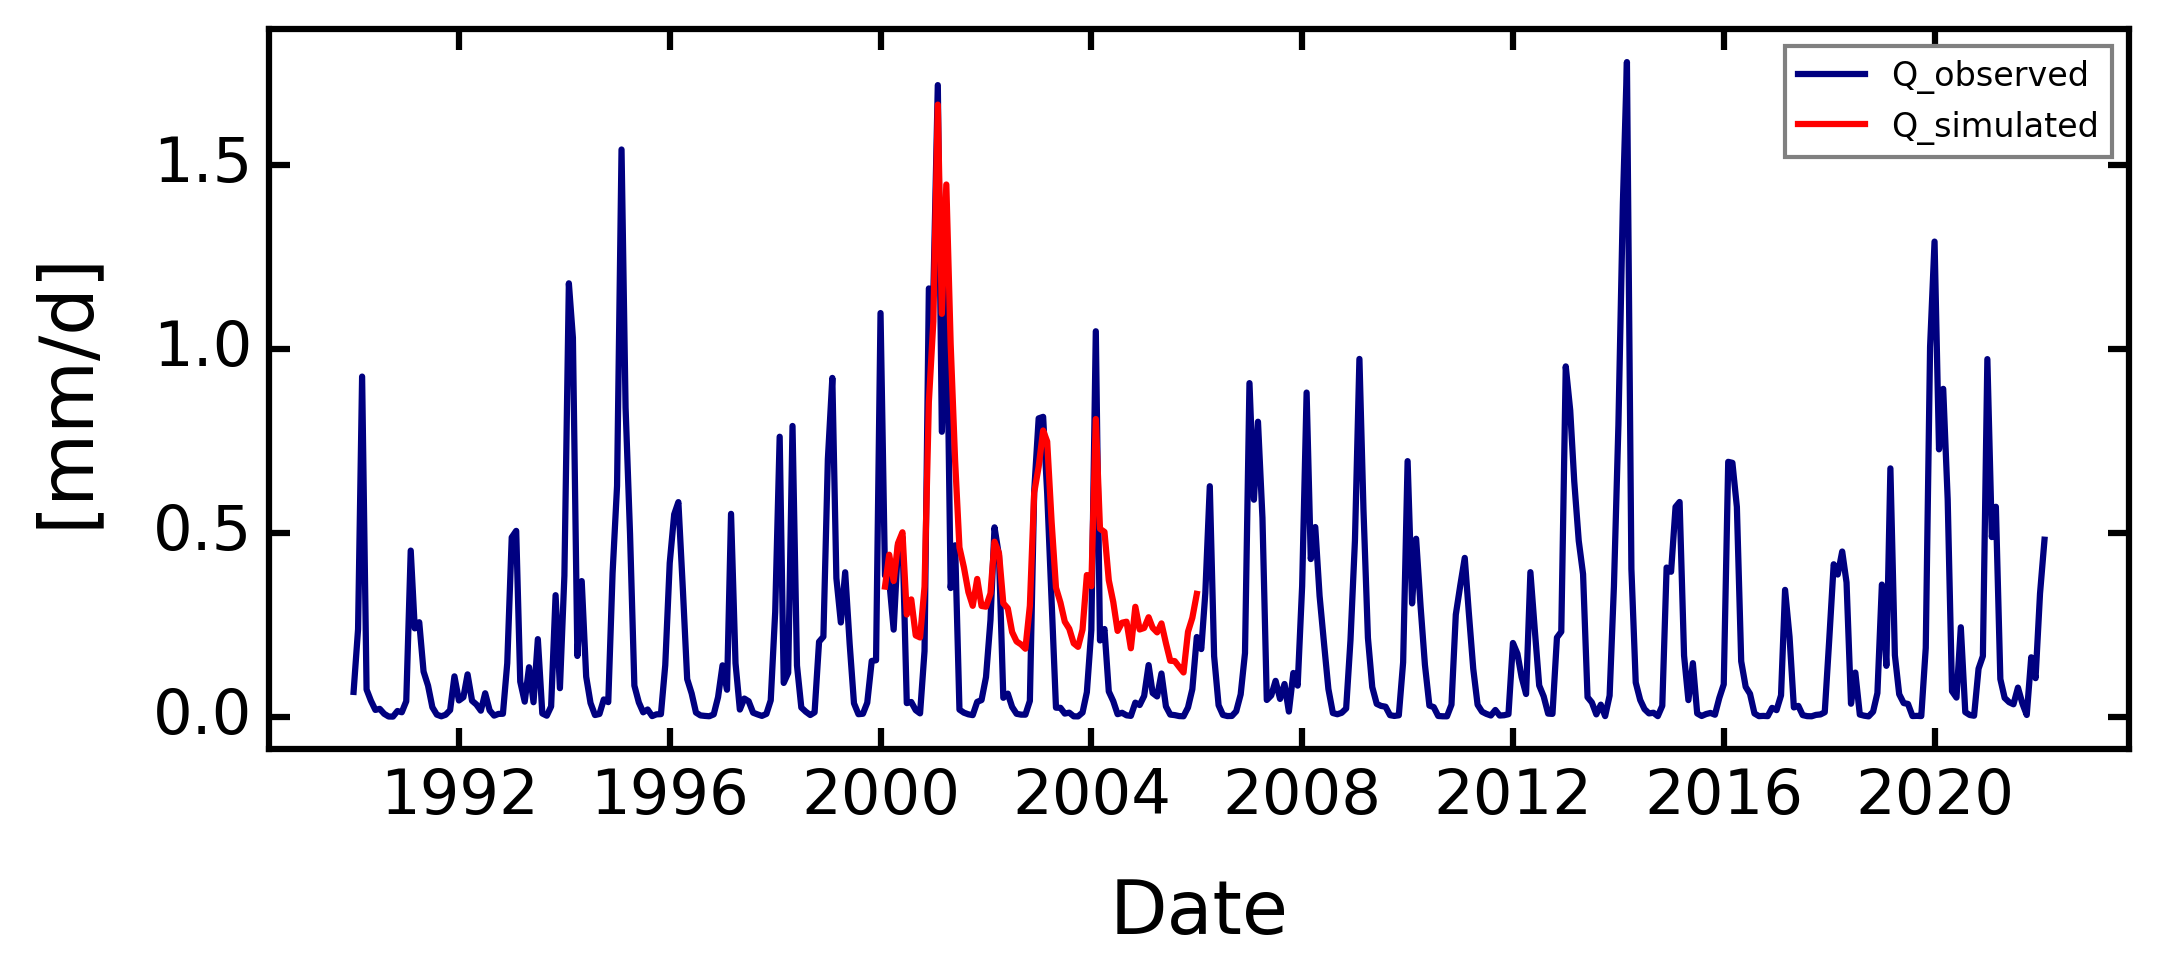

In [23]:
# Si le modèle tourne en régime permament, alors le résultat du régime permanent, qui donc ne dépend pas du temps,
# est affiché sur la première ligne des résultats. Si le modèle est en régime transitoire, à chaque pas de temps
# s'affiche le résultat

# Pour retrouver le débit simulé et comparer au débit observé:
Qmod_nappe = timeseries['outflow_drain']*1000
#print(Qmod_nappe)
Ruiss = timeseries['runoff']*1000
Qmod = Qmod_nappe + Ruiss
Qobs_path = data_path + 'hydrometry catchment Canut.csv'
Qobs = pd.read_csv(Qobs_path, sep=';', index_col=0, parse_dates=True)
Qobs = Qobs.resample('M').mean()

# Exemple de code pour faire des figures à partir de time series.
fig, ax = plt.subplots(1,1, figsize=(8,3))
ax.plot(Qobs, label='Q_observed', c='navy', lw=1.5)
ax.plot(Qmod*0.5, label='Q_simulated', c='red', lw=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/d]')
ax.legend()